# Debug 03: same function, two run names

This notebook compares two SMAC runs created by the exact same Python function. The only intended difference is the `run_label`, which changes the scenario name/output directory.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 668,

In [2]:
ROOT = Path("/home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug_03")
RESULT_DIRECTORY = ROOT / "same_function_two_names"
RUN_LABELS = ["same_function_a", "same_function_b"]
SEED = 0
RUN_DIRS = {label: RESULT_DIRECTORY / label / str(SEED) for label in RUN_LABELS}
FIGURE_DIRECTORY = ROOT / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

for label, run_dir in RUN_DIRS.items():
    print(label, run_dir, run_dir.exists())

same_function_a /home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug_03/same_function_two_names/same_function_a/0 True
same_function_b /home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug_03/same_function_two_names/same_function_b/0 True


## Helpers

In [3]:
def load_json(path: Path) -> dict:
    with open(path) as fh:
        return json.load(fh)


def ordered_trials(run_dir: Path) -> list[dict]:
    runhistory = load_json(run_dir / "runhistory.json")
    configs = {str(config_id): config for config_id, config in runhistory["configs"].items()}
    origins = {str(config_id): origin for config_id, origin in runhistory.get("config_origins", {}).items()}
    rows = sorted(runhistory["data"], key=lambda row: (row["starttime"], row["endtime"]))

    ordered = []
    for trial_number, row in enumerate(rows, start=1):
        config_id = str(row["config_id"])
        ordered.append(
            {
                "trial": trial_number,
                "config_id": config_id,
                "config": configs[config_id],
                "cost": float(row["cost"]),
                "origin": origins.get(config_id),
            }
        )
    return ordered


def best_so_far(costs):
    return np.minimum.accumulate(np.asarray(costs, dtype=float))

## Scenario metadata

In [4]:
metadata_rows = []
for label, run_dir in RUN_DIRS.items():
    scenario = load_json(run_dir / "scenario.json")
    meta = scenario.get("_meta", {})
    model = meta.get("model", {})
    initial_design = meta.get("initial_design", {})
    metadata_rows.append(
        {
            "run": label,
            "name": scenario.get("name"),
            "output_directory": scenario.get("output_directory"),
            "n_trials": scenario.get("n_trials"),
            "seed": scenario.get("seed"),
            "initial_design_n_configs": initial_design.get("n_configs"),
            "model_min_samples_leaf": model.get("min_samples_leaf"),
            "model_max_depth": model.get("max_depth"),
            "model_random_state": model.get("random_state"),
        }
    )

pd.DataFrame(metadata_rows)

,run,name,output_directory,n_trials,seed,initial_design_n_configs,model_min_samples_leaf,model_max_depth,model_random_state
0,same_function_a,same_function_a,/home/io632776/experiments/adaptive-smac/exper...,400,0,25,1,1048576,0
1,same_function_b,same_function_b,/home/io632776/experiments/adaptive-smac/exper...,400,0,25,1,1048576,0


## Trial-by-trial comparison

In [5]:
trials = {label: ordered_trials(run_dir) for label, run_dir in RUN_DIRS.items()}
a = trials[RUN_LABELS[0]]
b = trials[RUN_LABELS[1]]

comparison_rows = []
first_difference = None
for trial_a, trial_b in zip(a, b):
    same_config = trial_a["config"] == trial_b["config"]
    same_cost = np.isclose(trial_a["cost"], trial_b["cost"], rtol=0, atol=1e-15)
    if first_difference is None and (not same_config or not same_cost):
        first_difference = trial_a["trial"]

    comparison_rows.append(
        {
            "trial": trial_a["trial"],
            "same_config": same_config,
            "same_cost": bool(same_cost),
            f"{RUN_LABELS[0]}_cost": trial_a["cost"],
            f"{RUN_LABELS[1]}_cost": trial_b["cost"],
            f"{RUN_LABELS[0]}_origin": trial_a["origin"],
            f"{RUN_LABELS[1]}_origin": trial_b["origin"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
print("first_difference:", first_difference)
comparison_df.head(35)

first_difference: 26


,trial,same_config,same_cost,same_function_a_cost,same_function_b_cost,same_function_a_origin,same_function_b_origin
0,1,True,True,-0.034167,-0.034167,Initial Design: Sobol,Initial Design: Sobol
1,2,True,True,-0.157265,-0.157265,Initial Design: Sobol,Initial Design: Sobol
2,3,True,True,-0.117585,-0.117585,Initial Design: Sobol,Initial Design: Sobol
3,4,True,True,-0.164613,-0.164613,Initial Design: Sobol,Initial Design: Sobol
4,5,True,True,-0.108812,-0.108812,Initial Design: Sobol,Initial Design: Sobol
5,6,True,True,-0.143232,-0.143232,Initial Design: Sobol,Initial Design: Sobol
6,7,True,True,-0.150772,-0.150772,Initial Design: Sobol,Initial Design: Sobol
7,8,True,True,-0.039170,-0.039170,Initial Design: Sobol,Initial Design: Sobol
8,9,True,True,-2.374172,-2.374172,Initial Design: Sobol,Initial Design: Sobol
9,10,True,True,-0.036580,-0.036580,Initial Design: Sobol,Initial Design: Sobol


In [6]:
if first_difference is not None:
    display(comparison_df[comparison_df["trial"].between(max(1, first_difference - 5), first_difference + 5)])
    config_a = a[first_difference - 1]["config"]
    config_b = b[first_difference - 1]["config"]
    diff_df = pd.DataFrame({RUN_LABELS[0]: config_a, RUN_LABELS[1]: config_b})
    diff_df["abs_diff"] = (diff_df[RUN_LABELS[0]] - diff_df[RUN_LABELS[1]]).abs()
    display(diff_df)
else:
    print("Runs are identical trial-by-trial.")

,trial,same_config,same_cost,same_function_a_cost,same_function_b_cost,same_function_a_origin,same_function_b_origin
20,21,True,True,-0.346825,-0.346825,Initial Design: Sobol,Initial Design: Sobol
21,22,True,True,-0.007197,-0.007197,Initial Design: Sobol,Initial Design: Sobol
22,23,True,True,-0.091317,-0.091317,Initial Design: Sobol,Initial Design: Sobol
23,24,True,True,-0.001190,-0.001190,Initial Design: Sobol,Initial Design: Sobol
24,25,True,True,-0.414354,-0.414354,Initial Design: Sobol,Initial Design: Sobol
25,26,False,False,-0.637887,-1.013827,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
26,27,False,False,-0.283611,-0.084663,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
27,28,False,False,-0.102924,-2.099594,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
28,29,False,False,-2.457841,-1.352807,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
29,30,False,False,-2.002049,-2.435192,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search


,same_function_a,same_function_b,abs_diff
x1,0.377248,0.208014,0.169234
x2,0.982341,0.997305,0.014964
x3,0.935422,0.992409,0.056986
x4,0.960416,0.769347,0.191068
x5,0.113451,0.022204,0.091247
x6,0.084179,0.057280,0.026899


## Best-so-far trajectory plot

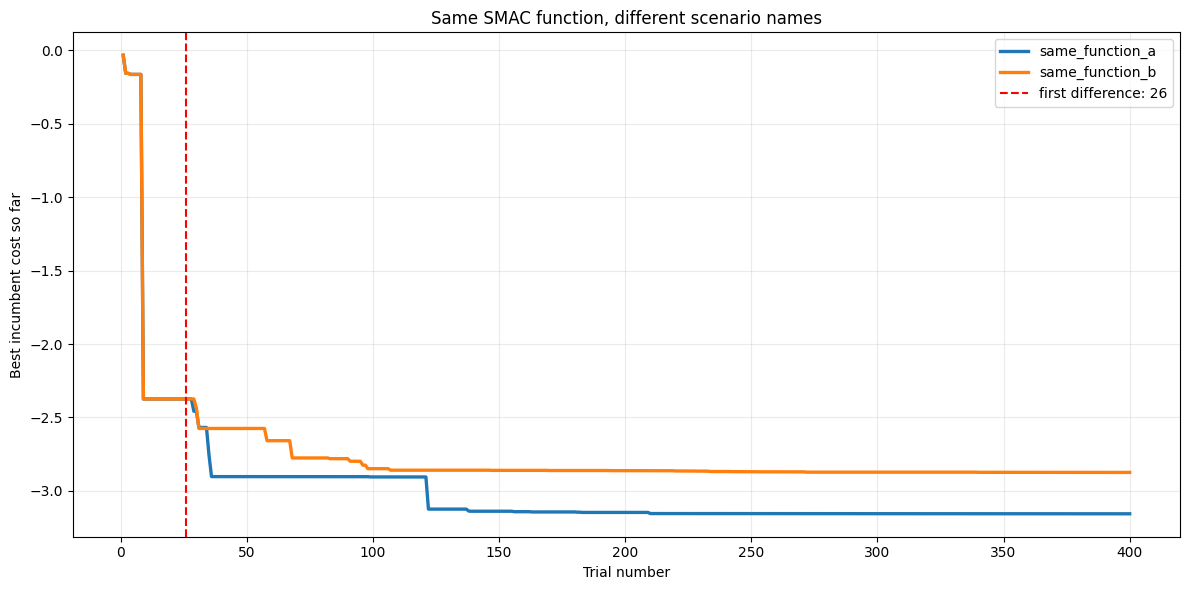

In [7]:
plt.figure(figsize=(12, 6))
for label in RUN_LABELS:
    costs = np.asarray([trial["cost"] for trial in trials[label]])
    trajectory = best_so_far(costs)
    plt.plot(np.arange(1, len(trajectory) + 1), trajectory, label=label, linewidth=2.4)

if first_difference is not None:
    plt.axvline(first_difference, color="red", linestyle="--", label=f"first difference: {first_difference}")
plt.title("Same SMAC function, different scenario names")
plt.xlabel("Trial number")
plt.ylabel("Best incumbent cost so far")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "same_function_two_names_best_so_far.png", dpi=200)
plt.show()

## Raw cost plot

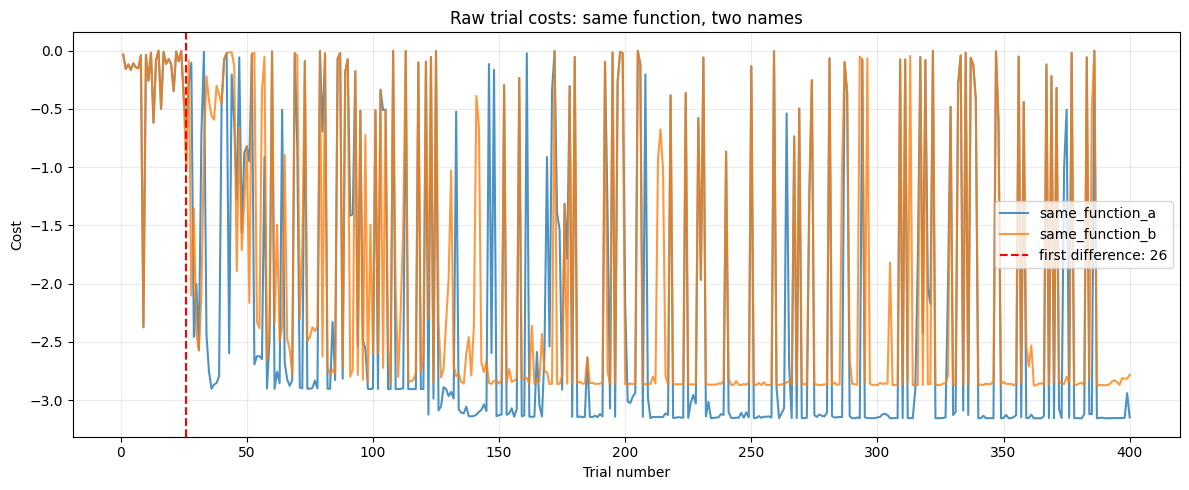

In [8]:
plt.figure(figsize=(12, 5))
for label in RUN_LABELS:
    costs = np.asarray([trial["cost"] for trial in trials[label]])
    plt.plot(np.arange(1, len(costs) + 1), costs, label=label, alpha=0.8)

if first_difference is not None:
    plt.axvline(first_difference, color="red", linestyle="--", label=f"first difference: {first_difference}")
plt.title("Raw trial costs: same function, two names")
plt.xlabel("Trial number")
plt.ylabel("Cost")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "same_function_two_names_raw_costs.png", dpi=200)
plt.show()